<a href="https://colab.research.google.com/github/MalgosiaKacp/Projekt/blob/main/ProjektML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing

Małgorzata Kacprzak, Piotr Dylak, Mikołaj Ostrowski

Zbuduj klasyfikator przewidujący status studenta na koniec standardowego okresu trwania studiów — jedną z trzech kategorii:
* dropout (rezygnacja),
* enrolled (wciąż zapisany),
* graduate (ukończył studia).

Wykorzystaj zbiór danych utworzony na podstawie kilku niezależnych baz z instytucji szkolnictwa wyższego. Każda instancja w zbiorze odpowiada jednemu studentowi zapisującemu się na różne kierunki licencjackie, takie jak: agronomia, design, pedagogika, pielęgniarstwo, dziennikarstwo, zarządzanie, praca socjalna.Zbiór zawiera informacje dostępne w momencie rekrutacji, obejmujące ścieżkę edukacyjną, dane demograficzne oraz czynniki społeczno‑ekonomiczne.Dane zostały stworzone w ramach projektu mającego na celu zmniejszenie liczby rezygnacji i niepowodzeń akademickich poprzez wczesną identyfikację studentów zagrożonych trudnościami.Projekt został sfinansowany w ramach programu SATDAP – Capacitação da Administração Pública, grant POCI‑05‑5762‑FSE‑000191 (Portugalia).

### Montowanie Dysku Google

Ten kod pozwoli Ci zamontować Dysk Google do środowiska Colab. Po uruchomieniu tej komórki, zostaniesz poproszony o autoryzację dostępu do swojego konta Google.

Pamiętaj, że musisz najpierw umieścić swój plik `student_dropout.csv` w publicznie dostępnym miejscu i wygenerować do niego bezpośredni link. Jeśli używasz Google Drive, musisz udostępnić plik publicznie i użyć odpowiedniego formatu linku, który pozwoli na bezpośrednie pobranie.

In [81]:
# https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success - opis zmiennych

In [82]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold

In [83]:
# Przykład publicznego pliku CSV z GitHub.
# Zastąp ten URL linkiem do 'raw' wersji Twojego pliku CSV na GitHub.
github_raw_url = 'https://raw.githubusercontent.com/MalgosiaKacp/Projekt/refs/heads/main/student_dropout.csv'

try:
    df = pd.read_csv(github_raw_url)
    print("Dane wczytane z GitHub:")
    display(df.head())
except Exception as e:
    print(f"Wystąpił błąd podczas wczytywania pliku z GitHub: {e}")
    print("Upewnij się, że link jest poprawny i prowadzi do 'raw' wersji pliku CSV.")

Dane wczytane z GitHub:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1.0,17,5,171,1,1,122.0,1,19.0,12.0,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1.0,15,1,9254,1,1,160.0,1,1.0,3.0,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1.0,1,5,9070,1,1,122.0,1,37.0,37.0,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1.0,17,2,9773,1,1,122.0,1,38.0,37.0,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2.0,39,1,8014,0,1,100.0,1,37.0,38.0,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [84]:
# Wczytywanie danych
# df = pd.read_csv('/content/student_dropout.csv')

In [85]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1.0,17,5,171,1,1,122.0,1,19.0,12.0,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1.0,15,1,9254,1,1,160.0,1,1.0,3.0,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1.0,1,5,9070,1,1,122.0,1,37.0,37.0,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1.0,17,2,9773,1,1,122.0,1,38.0,37.0,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2.0,39,1,8014,0,1,100.0,1,37.0,38.0,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4406 non-null   float64
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4420 non-null   float64
 9   Father's qualification                   

In [87]:
# Usuwanie ewentualnych duplikatów
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4406 non-null   float64
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4420 non-null   float64
 9   Father's qualification                   

In [88]:
# zamiana wartości pustych na NaN
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(' ', np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4406 non-null   float64
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4420 non-null   float64
 9   Father's qualification                   

In [89]:
# sprawdzanie wartości w kolumnach - kolumna Gender jest niepoprawna
df['Gender'].value_counts()
# pozostałe kolumny posiadają możliwe wartości

,count
Gender,
18.00,1031
19.00,909
20.00,597
21.00,322
22.00,173
24.00,130
23.00,106
26.00,94
25.00,93


In [90]:
# usunięcie kolumny Gender
df.drop(columns=['Gender'], inplace=True)

In [91]:
# zamiana kolumn typu float które nie mają wartości ciągłych na integer
df['Marital status'].fillna(0, inplace=True)
df['Marital status'] = df['Marital status'].astype(int)

df['Mother\'s qualification'].fillna(0, inplace=True)
df['Mother\'s qualification'] = df['Mother\'s qualification'].astype(int)

df['Father\'s qualification'].fillna(0, inplace=True)
df['Father\'s qualification'] = df['Father\'s qualification'].astype(int)

df['Father\'s occupation'] = df['Father\'s occupation'].replace('(blank)', np.nan)
df['Mother\'s occupation'] = df['Mother\'s occupation'].replace('(blank)', np.nan)

/tmp/ipykernel_7073/1546741861.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marital status'].fillna(0, inplace=True)
/tmp/ipykernel_7073/1546741861.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [92]:
# zamiana stringów na liczby
col_to_change=['Mother\'s occupation', 'Father\'s occupation', 'Educational special needs','Debtor', 'Scholarship holder', 'International', 'Target']
for col in col_to_change:
    print(col)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    mapping = {i: label for i, label in enumerate(le.classes_)}
    print(mapping)

Mother's occupation
{0: 'Administrative staff', 1: 'Armed Forces Professions', 2: 'Data, accounting, statistical, financial services and registry-related operators', 3: 'Farmers and Skilled Workers in Agriculture, Fisheries and Forestry', 4: 'Health professionals', 5: 'Installation and Machine Operators and Assembly Workers', 6: 'Intermediate Level Technicians and Professions', 7: 'Intermediate level science and engineering technicians and professions', 8: 'Intermediate level technicians from legal, social, sports, cultural and similar services', 9: 'Meal preparation assistants', 10: 'Office workers, secretaries in general and data processing operators', 11: 'Other Situation', 12: 'Other administrative support staff', 13: 'Personal Services, Security and Safety Workers and Sellers', 14: 'Personal care workers and the like', 15: 'Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers', 16: 'Skilled Workers in Industry, Construction and

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [94]:
# zamiana nazw kolumn
df = df.rename(columns={'Nacionality': 'Nationality', 'Daytime/evening attendance\t': 'Attendance time'})

In [95]:
# sprawdzanie wartości w kolumnach typu float - kolumna Age at enrollemnt posiada niepoprawne wartości
df['Age at enrollment'].value_counts(sort = True)

,count
Age at enrollment,
18.00,1031
19.00,909
20.00,597
21.00,322
22.00,173
24.00,130
23.00,106
26.00,94
25.00,93


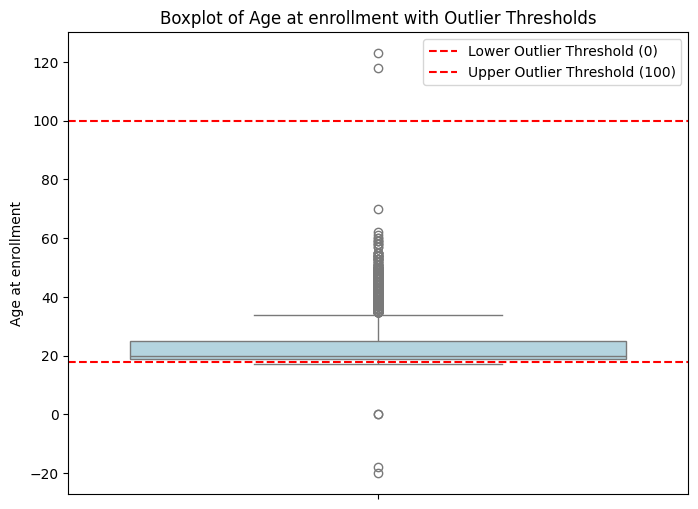

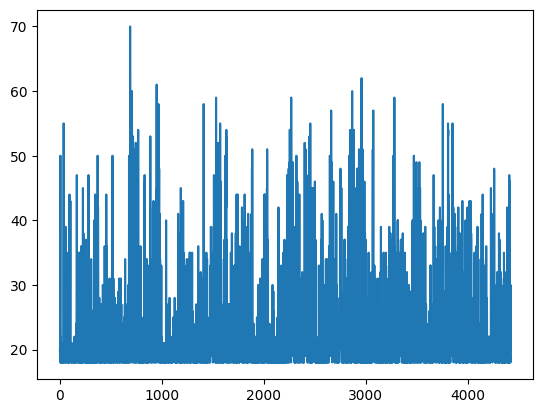

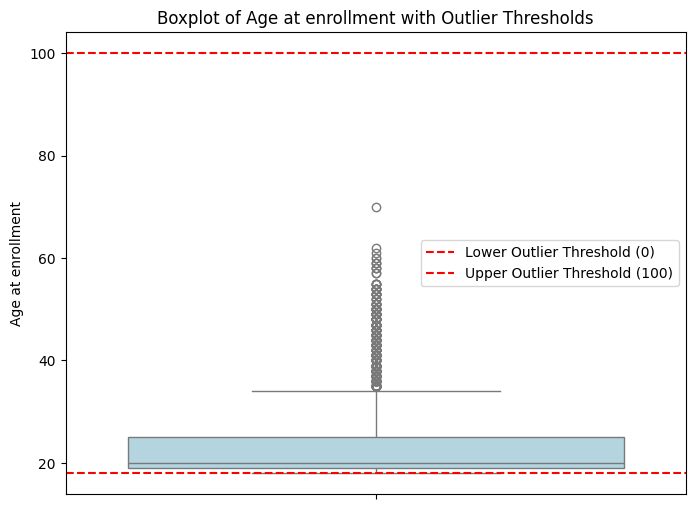

In [96]:
# usunięcie outlierów z kolumny Age at enrollment - dużo odstających wartości
col_age = 'Age at enrollment'

plt.figure(figsize=(8, 6))
sns.boxplot(y=df[col_age], color='lightblue')

plt.axhline(y=18, color='red', linestyle='--', label='Lower Outlier Threshold (0)')
plt.axhline(y=100, color='red', linestyle='--', label='Upper Outlier Threshold (100)')

plt.ylabel(col_age)
plt.title('Boxplot of Age at enrollment with Outlier Thresholds')
plt.legend()
plt.show()

print('')

mean_age = df[(df[col_age] >= 18) & (df[col_age] <= 100)][col_age].mean()
df.loc[(df[col_age] < 18) | (df[col_age] > 100), col_age] = mean_age
plt.plot(df[col_age])

print('')

plt.figure(figsize=(8, 6))
sns.boxplot(y=df[col_age], color='lightblue')

plt.axhline(y=18, color='red', linestyle='--', label='Lower Outlier Threshold (0)')
plt.axhline(y=100, color='red', linestyle='--', label='Upper Outlier Threshold (100)')

plt.ylabel('Age at enrollment')
plt.title('Boxplot of Age at enrollment with Outlier Thresholds')
plt.legend()
plt.show()

In [97]:
# Pozostałe kolumny posiadją nieznaczne wartości odstające, jednak mieszczą się one w zakresie podanym w opisie danych

In [98]:
# skalowanie zmiennych
scaler = RobustScaler()

for i in df:
  df[i] = scaler.fit_transform(df[[i]])

print(df.head())


   Marital status  Application mode  Application order     Course  \
0             0.0          0.000000                4.0 -19.250531   
1             0.0         -0.052632                0.0   0.033970   
2             0.0         -0.421053                4.0  -0.356688   
3             0.0          0.000000                1.0   1.135881   
4             1.0          0.578947                0.0  -2.598726   

   Attendance time  Previous qualification  Previous qualification (grade)  \
0              0.0                     0.0                       -0.740000   
1              0.0                     0.0                        1.793333   
2              0.0                     0.0                       -0.740000   
3              0.0                     0.0                       -0.740000   
4             -1.0                     0.0                       -2.206667   

   Nationality  Mother's qualification  Father's qualification  ...  \
0          0.0                0.000000       

                                                Marital status  \
Marital status                                        1.000000   
Application mode                                      0.261455   
Application order                                    -0.124328   
Course                                                0.046131   
Attendance time                                      -0.272858   
Previous qualification                                0.061100   
Previous qualification (grade)                       -0.024380   
Nationality                                          -0.007935   
Mother's qualification                                0.193926   
Father's qualification                                0.129245   
Mother's occupation                                   0.079224   
Father's occupation                                   0.046674   
Admission grade                                      -0.004720   
Displaced                                            -0.231750   
Educationa

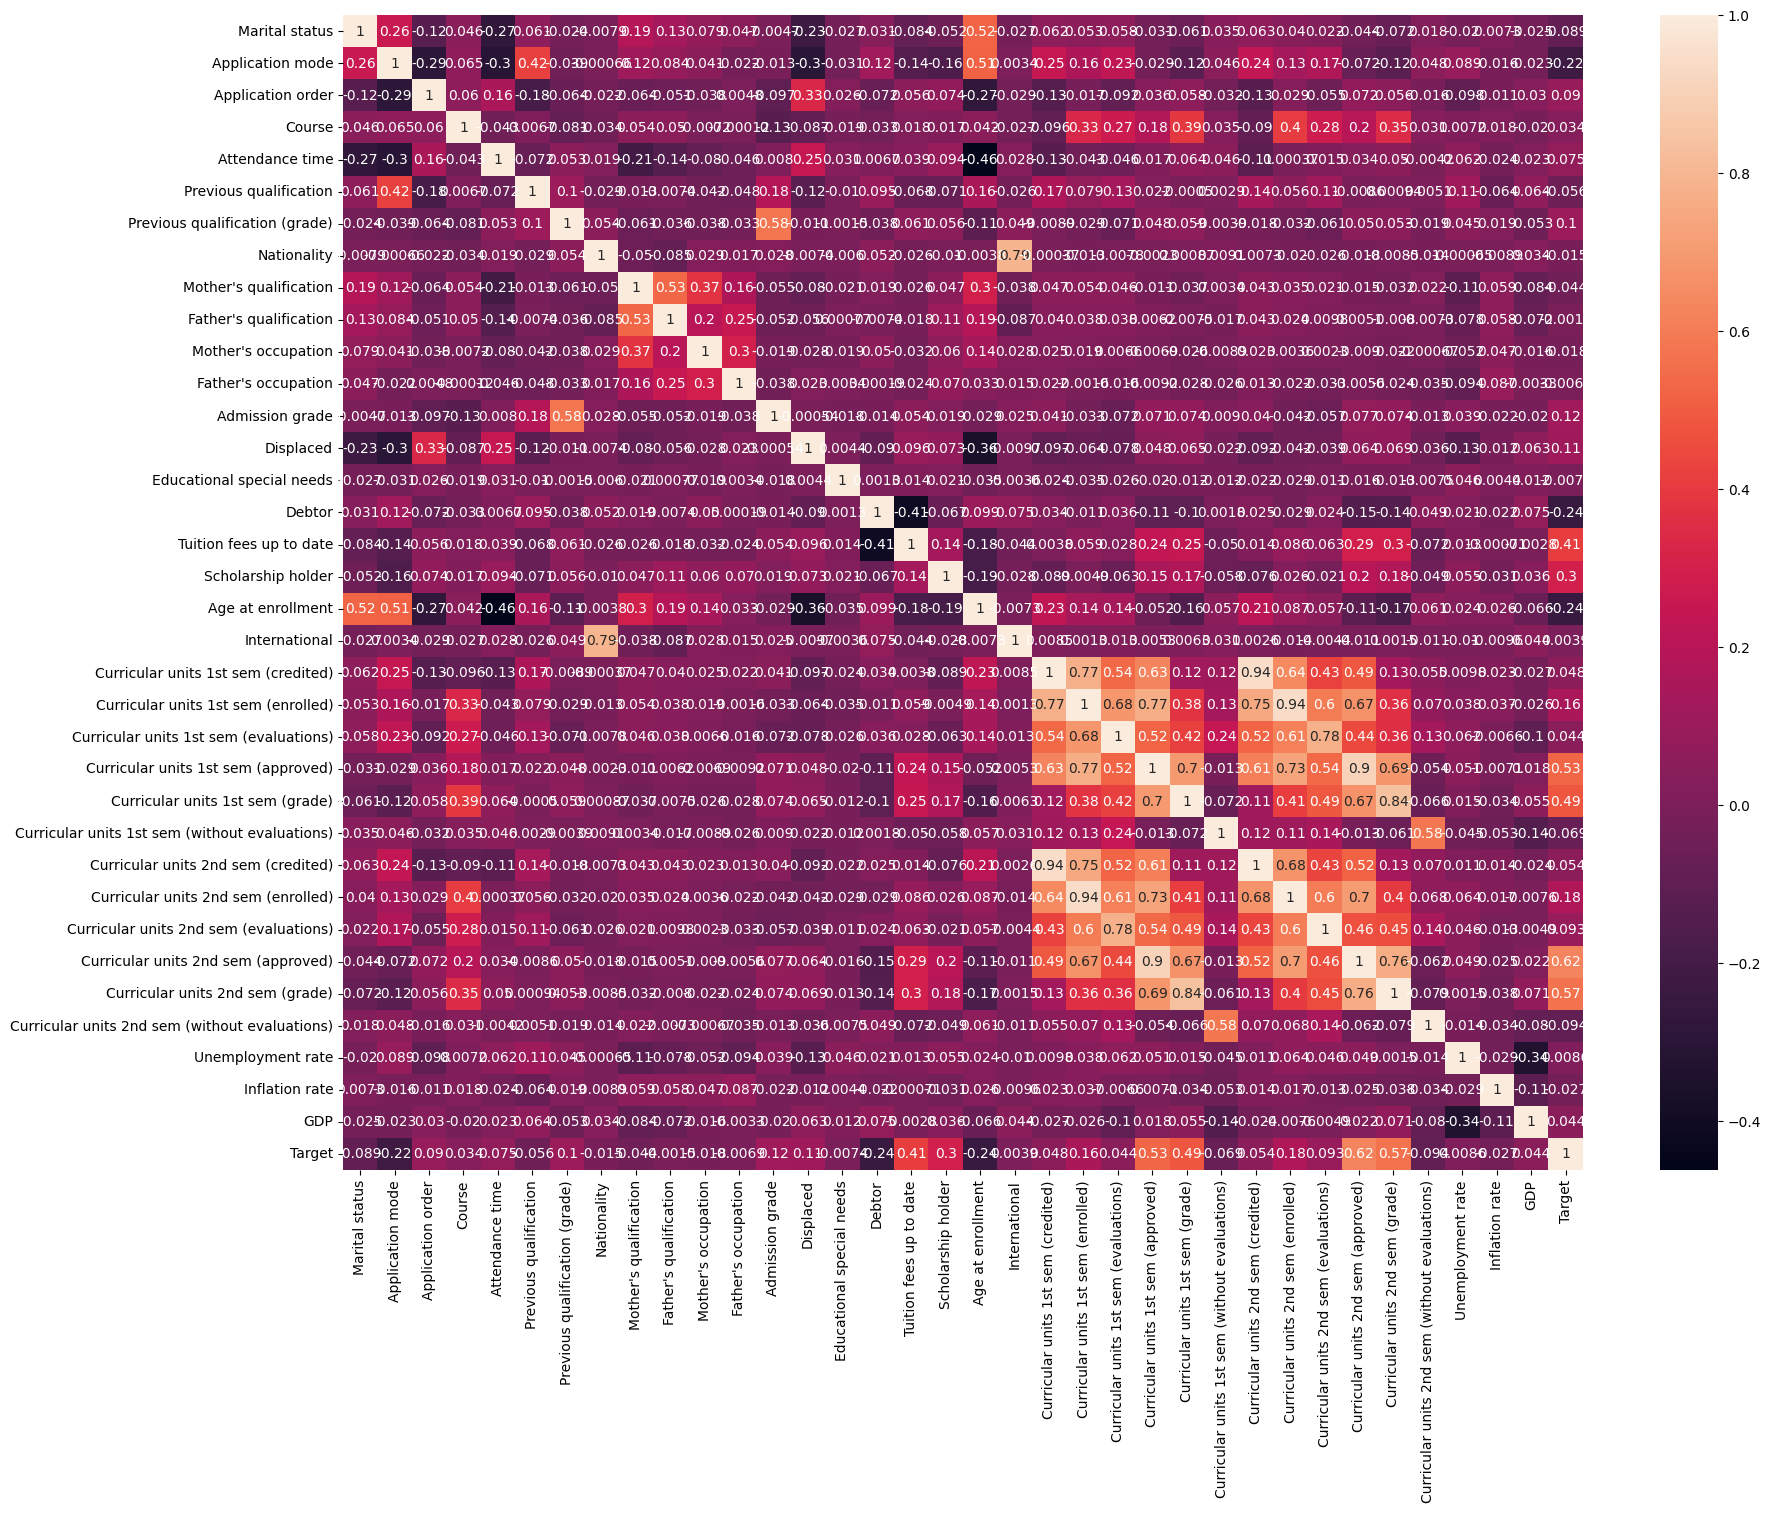

In [99]:
# Macierz korelacji
corr_matrix = df.corr()
print(corr_matrix)
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True)
plt.show()

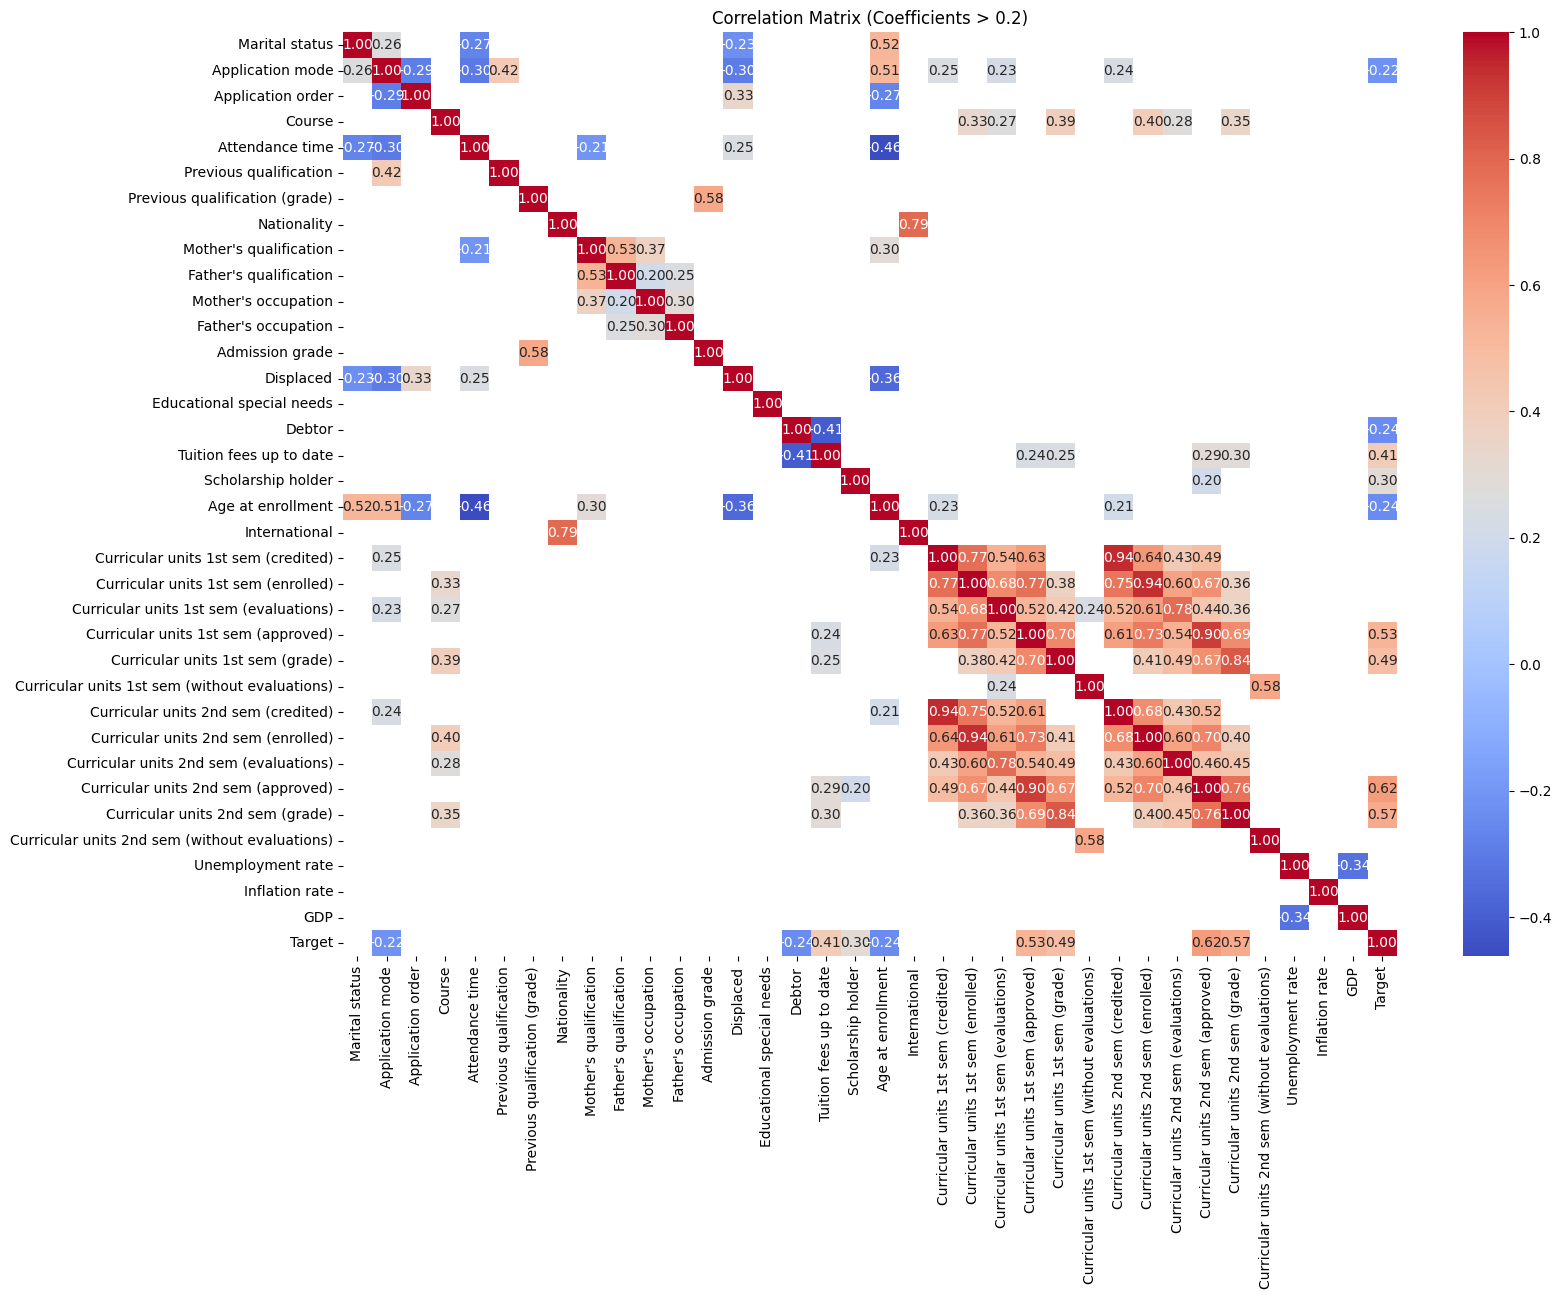

In [100]:
# Korelacja większa od 0.2
corr_matrix = df.corr()
high_corr = corr_matrix[abs(corr_matrix) > 0.2]
plt.figure(figsize=(17, 12))
sns.heatmap(high_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Coefficients > 0.2)')
plt.show()

In [101]:
# usunięcie kolumn o wysokiej korelacji
df.drop(columns=['Curricular units 2nd sem (credited)'], inplace=True)
df.drop(columns=['Curricular units 2nd sem (enrolled)'], inplace=True)
df.drop(columns=['Curricular units 2nd sem (approved)'], inplace=True)

In [102]:
# Usuwanie cech stałych
selector = VarianceThreshold(threshold=0.01)
selector.fit(df)
mask = selector.get_support()
kept_cols = df.columns[mask]
print(kept_cols)
X = df[kept_cols].copy()
print("Przed dropna:", X.shape)
X.dropna(inplace=True)
print("Po dropna:", X.shape)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Attendance time', 'Previous qualification',
       'Previous qualification (grade)', 'Nationality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment',
       'International', 'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target'],
      dtype='object')
Przed drop

In [103]:
# PCA
np.set_printoptions(precision=8, suppress=True)
pca = PCA()
X_pca = pca.fit_transform(X)
print(pca.explained_variance_)
print(pca.components_)
pca_final = PCA(n_components=6)
X_final = pca_final.fit_transform(X)
print(X_final.shape)

[105.04073419  47.91704746  21.47101985   8.93009664   5.31858156
   1.96270846   1.30801873   1.13048629   0.99191214   0.70742902
   0.58329757   0.5159314    0.47999032   0.34901825   0.33583343
   0.30312852   0.27291209   0.24500922   0.23203746   0.21241668
   0.19731579   0.18196994   0.17517979   0.15992864   0.13744984
   0.11518825   0.10197863   0.08346611   0.06918192   0.0633884
   0.05555167   0.01132328   0.00894447]
[[ 0.003822    0.01917778 -0.02415264 ... -0.00376143  0.00396927
  -0.00238209]
 [-0.00045606  0.00141016 -0.00669025 ... -0.00111679  0.00361188
  -0.00130525]
 [ 0.00355131  0.00374715  0.01914326 ...  0.00117678 -0.00079421
   0.0151203 ]
 ...
 [ 0.0094909  -0.02927098  0.00110512 ...  0.00235558 -0.01909001
  -0.37773862]
 [ 0.00206733  0.00503347 -0.00207749 ... -0.00192866 -0.00563062
   0.00592241]
 [ 0.00694004 -0.00316556  0.00119432 ...  0.00003168 -0.00446846
  -0.0208828 ]]
(4413, 6)


In [104]:
# sprawdzenie ile komponentów jest potrzebne do wyjaśnienia 95% wariancji (do PCA)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Explained Variance Ratio per Component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Component {i+1}: {ratio:.4f}")

print("\nCumulative Explained Variance:")
for i, cum_ratio in enumerate(cumulative_explained_variance):
    print(f"Components 1 to {i+1}: {cum_ratio:.4f}")

Explained Variance Ratio per Component:
Component 1: 0.5261
Component 2: 0.2400
Component 3: 0.1075
Component 4: 0.0447
Component 5: 0.0266
Component 6: 0.0098
Component 7: 0.0066
Component 8: 0.0057
Component 9: 0.0050
Component 10: 0.0035
Component 11: 0.0029
Component 12: 0.0026
Component 13: 0.0024
Component 14: 0.0017
Component 15: 0.0017
Component 16: 0.0015
Component 17: 0.0014
Component 18: 0.0012
Component 19: 0.0012
Component 20: 0.0011
Component 21: 0.0010
Component 22: 0.0009
Component 23: 0.0009
Component 24: 0.0008
Component 25: 0.0007
Component 26: 0.0006
Component 27: 0.0005
Component 28: 0.0004
Component 29: 0.0003
Component 30: 0.0003
Component 31: 0.0003
Component 32: 0.0001
Component 33: 0.0000

Cumulative Explained Variance:
Components 1 to 1: 0.5261
Components 1 to 2: 0.7661
Components 1 to 3: 0.8736
Components 1 to 4: 0.9183
Components 1 to 5: 0.9450
Components 1 to 6: 0.9548
Components 1 to 7: 0.9613
Components 1 to 8: 0.9670
Components 1 to 9: 0.9720
Components